In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [15]:
df= pd.read_csv("/content/customer_churn_data.csv")

In [5]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [ ]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


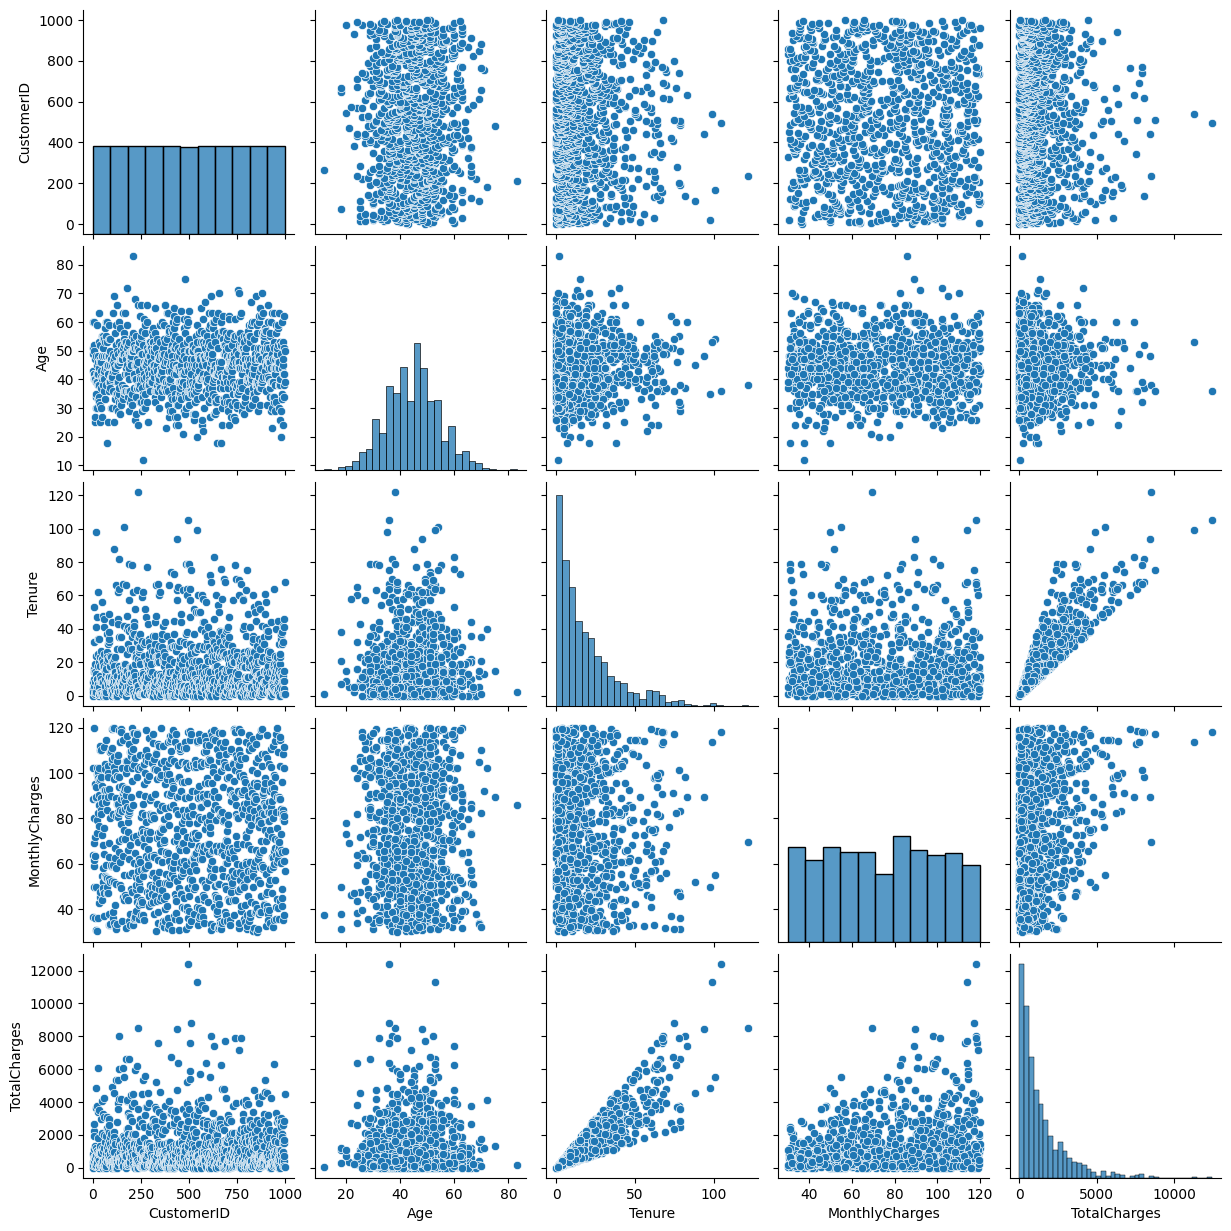

In [ ]:
sns.pairplot(df)
plt.show

In [ ]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

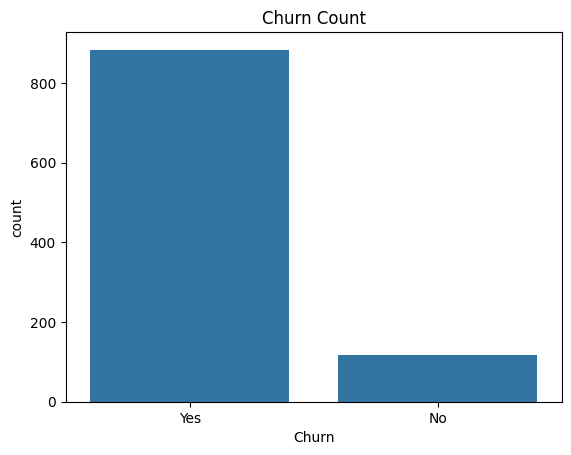

In [ ]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Count')
plt.show()

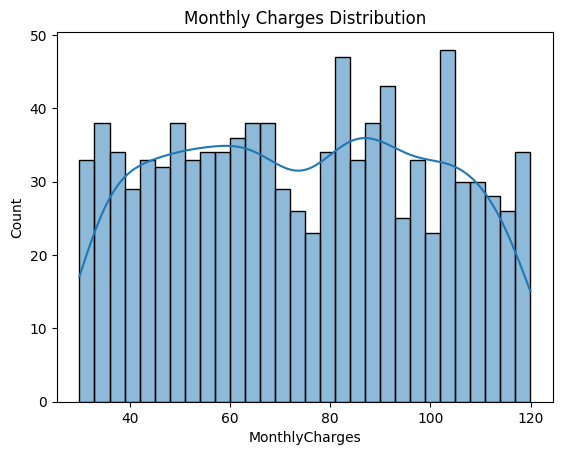

In [ ]:
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

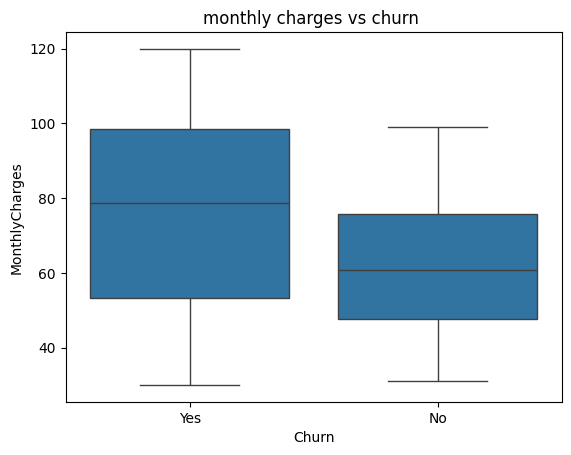

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data= df)
plt.title('monthly charges vs churn ')
plt.show()

In [6]:
df = pd.get_dummies(df, columns=['ContractType', 'InternetService'], drop_first=True)

In [7]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,TotalCharges,TechSupport,Churn,ContractType_One-Year,ContractType_Two-Year,InternetService_Fiber Optic
0,1,49,Male,4,88.35,353.40,Yes,Yes,False,False,True
1,2,43,Male,0,36.67,0.00,Yes,Yes,False,False,True
2,3,51,Female,2,63.79,127.58,No,Yes,False,False,True
3,4,60,Female,8,102.34,818.72,Yes,Yes,True,False,False
4,5,42,Male,32,69.01,2208.32,No,Yes,False,False,False


In [ ]:
# using linear reg

In [9]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['TechSupport'] = df['TechSupport'].map({'Yes': 1, 'No': 0})
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [13]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,TotalCharges,TechSupport,Churn,ContractType_One-Year,ContractType_Two-Year,InternetService_Fiber Optic
0,1,49,1,4,88.35,353.40,1,1,False,False,True
1,2,43,1,0,36.67,0.00,1,1,False,False,True
2,3,51,0,2,63.79,127.58,0,1,False,False,True
3,4,60,0,8,102.34,818.72,1,1,True,False,False
4,5,42,1,32,69.01,2208.32,0,1,False,False,False


In [18]:
X = df.drop('Churn', axis=1)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.6, random_state=42
)

In [21]:
X['Gender'] = X['Gender'].map({'Male': 1, 'Female': 0})
X['TechSupport'] = X['TechSupport'].map({'Yes': 1, 'No': 0})
X = pd.get_dummies(X, columns=['ContractType', 'InternetService'], drop_first=True)

display(X.head())

,CustomerID,Age,Gender,Tenure,MonthlyCharges,TotalCharges,TechSupport,ContractType_One-Year,ContractType_Two-Year,InternetService_Fiber Optic
0,1,49,1,4,88.35,353.40,1,False,False,True
1,2,43,1,0,36.67,0.00,1,False,False,True
2,3,51,0,2,63.79,127.58,0,False,False,True
3,4,60,0,8,102.34,818.72,1,True,False,False
4,5,42,1,32,69.01,2208.32,0,False,False,False


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.6, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train shape after scaling:", X_train.shape)
print("X_test shape after scaling:", X_test.shape)

X_train shape after scaling: (400, 10)
X_test shape after scaling: (600, 10)


In [34]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [36]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [37]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [38]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[ 73   0]
 [ 73 454]]
              precision    recall  f1-score   support

          No       0.50      1.00      0.67        73
         Yes       1.00      0.86      0.93       527

    accuracy                           0.88       600
   macro avg       0.75      0.93      0.80       600
weighted avg       0.94      0.88      0.89       600

ROC-AUC: 0.9826882586883627


In [39]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(importance)

                       Feature  Coefficient
4               MonthlyCharges     0.882788
2                       Gender     0.288527
1                          Age     0.051895
9  InternetService_Fiber Optic    -0.015569
0                   CustomerID    -0.138881
5                 TotalCharges    -0.404795
3                       Tenure    -1.088915
8        ContractType_Two-Year    -2.456401
7        ContractType_One-Year    -2.870956
6                  TechSupport    -3.194671
